## Mini Project: Defining a Multiview operator


In this mini project, you will define a linear multiview operator which measures $J$ measurement vectors $y_1,\dots,y_J$ of a single image $x$, following the model
$$
y_j = AT_jx \text{ for } j=1,\dots,J
$$
where $A$ is an arbritrary forward operator (eg downsampling), and $T_j$ are affine transformations defined by $2\times 3$ matrices, which include translations, rotations and shearing.

The **goal** of this project is to use this definition to reconstruct a series of downsampled measurements with random rotations and shifts.

**DeepInverse Documentation**: https://deepinv.github.io/

**Tip**: you can check out the ["defining your own operator"](https://deepinv.github.io/deepinv/auto_examples/basics/demo_physics.html#sphx-glr-auto-examples-basics-demo-physics-py)  example in the documentation if you get stuck!

In [ ]:
%%capture
pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv

In [ ]:
import torch
import deepinv as dinv
from torchvision import transforms
import matplotlib.pyplot as plt

### Step 1: Download the library and the multiview measurements

We start by downloading the latest version of deepinverse, and download the
$J=16$ measurements we wish to reconstruct which are noisy low-res color images of size $64 \times 64$. We will also download the registration parameters of the measurements which are matrices of size $2\times 3$. This step is already finished, so you can start directly with step 2.




In [ ]:
# download dataset
from huggingface_hub import hf_hub_download
path = hf_hub_download(repo_id="jtachella/finetuning", repo_type="dataset", filename="multiview_data.pth")

multiview_data.pth:   0%|          | 0.00/788k [00:00<?, ?B/s]

measurements shape  torch.Size([1, 16, 3, 64, 64]) transforms shape torch.Size([16, 2, 3])


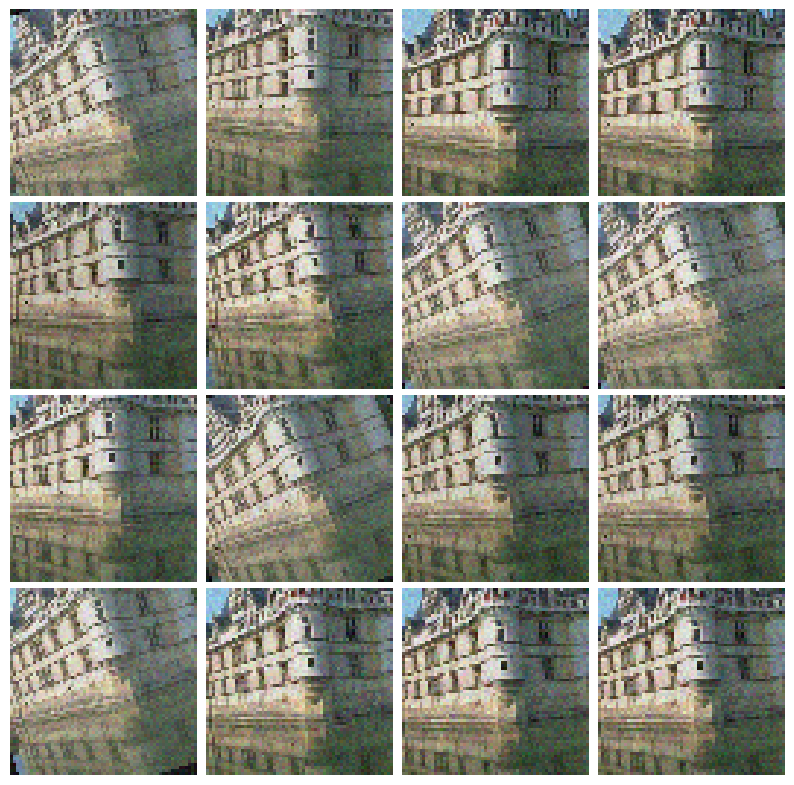

In [ ]:
data = torch.load(path, map_location=torch.device('cpu'))

y = data['y'] # measurements (1, 16, 3, 64, 64)
transf = data['transf'] # transforms (16, 2, 3)

print('measurements shape ', y.shape, 'transforms shape', transf.shape)
dinv.utils.plot([y[0, :4, ...], y[0, 4:8, ...], y[0, 8:12, ...], y[0, 8:16, ...]], figsize=(10, 10))

### Step 2: Define the LinearPhysics class

We can now define the multiview class.
In this example, we will use the [downsampling operator]() as the common $A$ operator across all measurements.

The image $x$ should have a size $(B, C, H, W)$ and the measurements $y_j$ should have a size $(B, J, C, H / 4, W / 4)$ where $B$ is the batch size, $J=16$ is the number of transforms, $C=3$ is the number of channels and $H=W=256$ are the number of pixels.

We recommend using [torch.nn.functional.affine_grid]() and [torch.nn.functional.grid_sample]() to compute the $T_i$ transforms.


**Tip 1**: the transformation matrices should be considered as [auxiliary operator parameters](https://deepinv.github.io/deepinv/user_guide/physics/intro.html#parameter-dependent-operators), such as blurs in the case of blind deblurring or MRI masks in the case of accelerated MRI. These parameters are generally updated using `physics.update`, which internally calls the private function `physics.update_parameters` (which you should define, see code demo below).

**Tip 2**: Defining the correct adjoint can be hard. If you cannot make it work, you can cheat and define it automatically using pytorch's autograd via [dinv.physics.adjoint_function](https://deepinv.github.io/deepinv/api/stubs/deepinv.physics.adjoint_function.html).


In [ ]:
base_physics = dinv.physics.Downsampling(factor=4, img_size=(3, 256, 256))
base_physics.set_noise_model(noise_model=dinv.physics.GaussianNoise(sigma=0.05))

In [ ]:
class MultiViewPhysics(dinv.physics.LinearPhysics):
  def __init__(self, base_physics, transf=None, device='cpu', **kwargs): # TODO
    self.base_physics=base_physics
    self.transf = transf
    self.device = device

  def A(self, x, **kwargs): # TODO
    return x

  def A_adjoint(self, y, **kwargs): # TODO
    return y

  def update_parameters(self, transf=None, **kwargs): # TODO
    if transf is not None:
      self.transf = transf


### Step 3: Test your operator on an image

Let's now make sure that the operator is well defined and working.

**Tip 1**: You can check whether the adjoint is well defined using an [adjointness test](https://deepinv.github.io/deepinv/api/stubs/deepinv.physics.LinearPhysics.html#deepinv.physics.LinearPhysics.adjointness_test), and also verify that the norm of the operator makes sense.

**Tip 2**: You can also check the operator norm using `compute_norm` which uses the [power iteration](https://en.wikipedia.org/wiki/Power_iteration) internally.


In [ ]:
# load image
x = dinv.utils.load_example("celeba_example.jpg", img_size=(256, 256), resize_mode='resize')

physics = MultiViewPhysics(base_physics)

# generate some random transformations
J = 16
transf2 = torch.zeros(J, 2, 3)
scale = .8
for i in range(J):
    angle =  torch.rand(1) * torch.pi / 8 # Random angle
    transf2[i, 0, 0] = torch.cos(angle) * scale
    transf2[i, 0, 1] = -torch.sin(angle) * scale
    transf2[i, 1, 0] = torch.sin(angle) * scale
    transf2[i, 1, 1] = torch.cos(angle) * scale
    transf2[i, :, -1] = torch.randn(2) * .05 # shift

physics.update(transf2=transf2)

y2 = physics(x) # compute measurements

print('Adjointness test', physics.adjointness_test(x)) # should be close to 0 if the adjoint is well defined
print('Operator norm', physics.compute_norm(x)) # the L2 norm of the linear operator

dinv.utils.plot([y2[0, :4, ...], y2[0, 4:8, ...], y2[0, 8:12, ...], y2[0, 8:16, ...]], figsize=(10, 10))

### Step 4: Use the linear physics to reconstruct the provided measurements

Let's try out the operator in the measurements provided by the mini-project.
Do you manage to improve the resolution of the measurements?

**Tip 1**: the library provides various [off-the-shelf linear solvers](https://deepinv.github.io/deepinv/api/stubs/deepinv.optim.utils.least_squares.html) to compute the linear pseudoinverse `A_dagger`, most of them being advanced variants of [conjugate gradient](https://en.wikipedia.org/wiki/Conjugate_gradient_method). You can change the solver to see how the reconstruction changes.

In [ ]:
physics = MultiViewPhysics(base_physics)
physics.update(transf=transf)

x_adj = physics.A_adjoint(y)
x_pseudoinv = physics.A_dagger(y, solver='lsqr')

dinv.utils.plot([x_adj, x_pseudoinv], titles=['adjoint', 'pseudoinverse'], figsize=(15, 15))

### Going Further

There are multiple ways to go beyond this simple example:

- Try out the multiview operator with more complex base $A$, such as [tomography](https://deepinv.github.io/deepinv/api/stubs/deepinv.physics.Tomography.html).
- Use learned regularization to obtain better reconstructions! Try some plug-and-play reconstruction using [dinv.optim.DPIR](https://deepinv.github.io/deepinv/api/stubs/deepinv.optim.DPIR.html) - are you getting better results?
- Can you estimate the transformations from the measurement data alone?